# Fraud Detection Using Machine Learning

## Task 3 — Fraud Detection

### What financial transaction fraud is

Financial transaction fraud is any transaction made without the legitimate account holder's authorisation —
a stolen card number used online, a cloned card, or an account taken over by an attacker. Each transaction
leaves a data trail (amount, timing, and other transaction characteristics), and the goal of this project is
to learn to separate that trail's fraudulent pattern from the overwhelming majority of genuine transactions.

### Why automated fraud detection is useful

Card networks process enormous volumes of transactions continuously — far more than any team of human
reviewers could check individually. An automated system that scores each transaction's fraud probability in
real time lets a business focus human review and blocking decisions on the small subset of transactions that
actually look suspicious, rather than either reviewing everything (impossible at scale) or nothing (leaving
fraud unchecked).

### Why this is a classification problem

Each transaction has a known, historical outcome — legitimate or fraudulent — recorded in the `Class`
column (confirmed in Step 3). Predicting which of these two categories a *new* transaction belongs to, from
its measurable characteristics, is a binary classification task.

### Why this dataset presents a major class-imbalance challenge

Fraudulent transactions are, by nature, rare relative to the enormous volume of legitimate activity. This is
confirmed with actual counts in Step 5, and it is the central challenge this entire notebook is built around
— nearly every design decision from here on (evaluation metrics, train/test splitting, SMOTE) exists
specifically to handle it correctly.

### The goal is not to maximize accuracy

With so few fraud cases, a model can achieve extremely high accuracy while catching almost no fraud at all
(demonstrated concretely in Step 6). The real objective is to **identify fraudulent transactions while
keeping false positives at a manageable level** — a trade-off explored throughout this notebook, not a single
number to maximise.


## Step 2 — Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

RANDOM_STATE = 42
print("Libraries imported successfully.")

Libraries imported successfully.


## Step 3 — Load the Dataset

This is the well-known Kaggle "Credit Card Fraud Detection" benchmark: anonymised transactions made by
European cardholders in September 2013. Loaded here without assuming its structure in advance — everything
below is confirmed directly from the file.

In [2]:
df = pd.read_csv("data/creditcard.csv")

print("Shape:", df.shape)
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,-1.593105,2.711941,-0.689256,4.626942,-0.924459,1.107641,1.991691,0.510632,-0.682920,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,-0.150189,0.915802,1.214756,-0.675143,1.164931,-0.711757,-0.025693,-1.221179,-1.545556,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,0.411614,0.063119,-0.183699,-0.510602,1.329284,0.140716,0.313502,0.395652,-0.577252,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,-1.933849,-0.962886,-1.042082,0.449624,1.962563,-0.608577,0.509928,1.113981,2.897849,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,-0.915427,-1.040458,-0.031513,-0.188093,-0.084316,0.041333,-0.302620,-0.660377,0.167430,-0.256117,0.382948,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [4]:
df.shape

(284807, 31)

In [5]:
df.columns.tolist()

['Time',
 'V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'Amount',
 'Class']

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [7]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,2.238554e-15,1.724421e-15,-1.245415e-15,8.238900e-16,1.213481e-15,4.866699e-15,1.436219e-15,-3.768179e-16,9.707851e-16,1.036249e-15,6.418678e-16,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,1.088850e+00,1.020713e+00,9.992014e-01,9.952742e-01,9.585956e-01,9.153160e-01,8.762529e-01,8.493371e-01,8.381762e-01,8.140405e-01,7.709250e-01,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,-2.458826e+01,-4.797473e+00,-1.868371e+01,-5.791881e+00,-1.921433e+01,-4.498945e+00,-1.412985e+01,-2.516280e+01,-9.498746e+00,-7.213527e+00,-5.449772e+01,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,-5.354257e-01,-7.624942e-01,-4.055715e-01,-6.485393e-01,-4.255740e-01,-5.828843e-01,-4.680368e-01,-4.837483e-01,-4.988498e-01,-4.562989e-01,-2.117214e-01,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,-9.291738e-02,-3.275735e-02,1.400326e-01,-1.356806e-02,5.060132e-02,4.807155e-02,6.641332e-02,-6.567575e-02,-3.636312e-03,3.734823e-03,-6.248109e-02,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,4.539234e-01,7.395934e-01,6.182380e-01,6.625050e-01,4.931498e-01,6.488208e-01,5.232963e-01,3.996750e-01,5.008067e-01,4.589494e-01,1.330408e-01,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,2.374514e+01,1.201891e+01,7.848392e+00,7.126883e+00,1.052677e+01,8.877742e+00,1.731511e+01,9.253526e+00,5.041069e+00,5.591971e+00,3.942090e+01,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


**What the dataset contains:**

- **Rows:** 284,807 individual transactions
- **Columns:** 31 total
- **Target variable:** `Class` — confirmed below to be `0` (legitimate) or `1` (fraudulent)
- **`Time`:** seconds elapsed since the first transaction in the dataset — **not a clock time** (examined
  properly in Step 8)
- **`Amount`:** the transaction amount
- **`V1` through `V28`:** 28 numerical features produced by PCA (Principal Component Analysis) on the
  original transaction data. Per the dataset's own documentation, the original features were transformed
  this way specifically to protect cardholder confidentiality, so these columns cannot be mapped back to
  real-world transaction attributes (e.g. merchant category, location) — they are used purely as anonymised
  numerical predictors.
- **Data types:** every column is numeric — `float64` for `Time`, `Amount`, and all 28 `V` features;
  `int64` for `Class`. There are no categorical columns to encode.

In [8]:
df["Class"].unique()

array([0, 1])

Confirmed: `Class` takes exactly two values, `0` and `1`, matching the documented meaning
(`0` = legitimate, `1` = fraudulent).

## Step 4 — Data Quality Check

In [9]:
df.isnull().sum().sum()

np.int64(0)

**No missing values found** anywhere in the dataset (sum of nulls across all 31 columns is 0).

In [10]:
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)
print("As a percentage of the dataset:", round(duplicate_count / len(df) * 100, 3), "%")

Duplicate rows: 1081
As a percentage of the dataset: 0.38 %


In [11]:
dup_rows = df[df.duplicated(keep=False)]
print("Rows involved in duplication:", len(dup_rows))
print("\nClass breakdown of duplicated rows:")
print(dup_rows["Class"].value_counts())

Rows involved in duplication: 1854

Class breakdown of duplicated rows:
Class
0    1822
1      32
Name: count, dtype: int64


**1,081 duplicate rows were found** (about 0.38% of the dataset). This is treated carefully rather than
dismissed automatically:

1. **Identification:** 1,081 groups of fully duplicated rows, involving 1,854 individual rows in total — of
   which 32 belong to the fraud class.
2. **Why this is a potential problem:** each row is a 31-value fingerprint across continuous PCA-transformed
   features plus `Time` and `Amount`. Two genuinely different transactions matching exactly across all 30
   continuous predictors is extremely unlikely by chance — these are far more likely to be the same
   transaction recorded more than once. Left in place, a duplicated row could end up split across the
   training and test sets, letting the exact same transaction "leak" information between them.
3. **Decision:** duplicates are removed, keeping the first occurrence of each.
4. **Records affected:** reported exactly below.

In [12]:
rows_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
rows_after = len(df)

print("Rows before removing duplicates:", rows_before)
print("Duplicate rows removed         :", rows_before - rows_after)
print("Rows remaining                 :", rows_after)

Rows before removing duplicates: 284807
Duplicate rows removed         : 1081
Rows remaining                 : 283726


In [13]:
df.dtypes.value_counts()

float64    30
int64       1
Name: count, dtype: int64

### Checking for invalid or suspicious values

Rather than assuming the data is clean, the actual ranges of `Time` and `Amount` (the two columns with
real-world, directly interpretable units) are checked for anything impossible.

In [14]:
df[["Time", "Amount"]].describe()

,Time,Amount
count,283726.000000,283726.000000
mean,94811.077600,88.472687
std,47481.047891,250.399437
min,0.000000,0.000000
25%,54204.750000,5.600000
50%,84692.500000,22.000000
75%,139298.000000,77.510000
max,172792.000000,25691.160000


**Finding:** `Time` runs from 0 to 172,792 seconds (= 48.0 hours — examined further in Step 8) with no
negative values, and `Amount` runs from \$0 to \$25,691.16 with no negative values — a transaction amount of
exactly \$0 is unusual but not impossible (e.g. an authorisation check or a fully-discounted transaction), so
it is not treated as invalid. No impossible values were found in either column, and the `V1`–`V28` PCA
features have no natural real-world range to sanity-check against (they are already anonymised numerical
transforms) — no rows are removed or altered for invalid values beyond the duplicate removal above.

## Step 5 — Class Imbalance Analysis

This is the central challenge of the entire project. The actual counts are calculated directly below —
nothing here is assumed in advance.

In [15]:
class_counts = df["Class"].value_counts()
class_percentages = df["Class"].value_counts(normalize=True) * 100

print("Class counts:")
print(class_counts)
print("\nClass percentages:")
print(class_percentages.round(4))

Class counts:
Class
0    283253
1       473
Name: count, dtype: int64

Class percentages:
Class
0    99.8333
1     0.1667
Name: proportion, dtype: float64


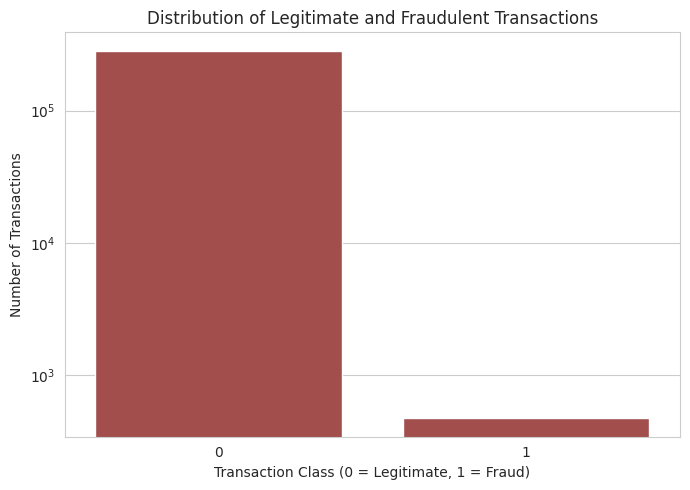

(Note: y-axis uses a log scale — on a linear scale the fraud bar would be visually invisible next
to the legitimate-transaction bar, which is itself a striking illustration of the imbalance.)


In [16]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Class", color="#B0413E")
plt.title("Distribution of Legitimate and Fraudulent Transactions")
plt.xlabel("Transaction Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.yscale("log")
plt.tight_layout()
plt.show()

print("(Note: y-axis uses a log scale — on a linear scale the fraud bar would be visually invisible next")
print("to the legitimate-transaction bar, which is itself a striking illustration of the imbalance.)")

**Actual numbers, after duplicate removal (Step 4):**

- **Total transactions:** 283,726
- **Legitimate transactions (`Class = 0`):** 283,253 (**99.833%**)
- **Fraudulent transactions (`Class = 1`):** 473 (**0.167%**)

In other words, roughly **1 in every 600 transactions** in this dataset is fraudulent. This is an extreme
imbalance — not a mild one — and it shapes every modelling decision from Step 10 (stratified splitting)
onward.

## Step 6 — Why Accuracy is Misleading Here

**A concrete hypothetical using this dataset's actual fraud rate:** with fraud at about 0.167% of
transactions, a model that predicts **every single transaction as legitimate** — without learning anything
at all — would be correct 99.833% of the time, simply because it agrees with the majority class by default.
That model would report an accuracy of over 99.8%, while catching **zero** fraudulent transactions. Accuracy
alone cannot tell the difference between a genuinely good model and this kind of useless shortcut.

**The four possible outcomes for each prediction:**

- **True Positive (TP):** the transaction was fraudulent, and the model correctly flagged it as fraud.
- **True Negative (TN):** the transaction was legitimate, and the model correctly let it through.
- **False Positive (FP):** the transaction was legitimate, but the model incorrectly flagged it as fraud.
- **False Negative (FN):** the transaction was fraudulent, but the model incorrectly classified it as
  legitimate.

**Why False Negatives are especially dangerous here:** a false negative means real fraud went completely
undetected — the transaction is approved as if nothing were wrong. The direct consequence is financial loss
(to the cardholder, the bank, or the merchant, depending on liability rules) and, if it happens repeatedly, a
fraudster who is never stopped. A false positive is also costly (see Step 19) — but a false negative is the
scenario where the system's entire purpose fails silently, with no chance to intervene after the fact.

**Why precision, recall, F1-score, and ROC-AUC are more informative than accuracy:** each of these can be
computed specifically with respect to the rare fraud class rather than being dominated by the huge legitimate
class the way plain accuracy is. **Recall** answers "of all the real fraud, how much did we catch?" —
directly addressing the false-negative danger above. **Precision** answers "of everything we flagged, how
much was actually fraud?" — directly addressing false-positive cost. **F1** balances the two, and
**ROC-AUC** summarises how well the model separates the two classes across every possible decision threshold,
not just the default one. All four are used throughout the rest of this notebook alongside accuracy, which is
still reported (Step 15) but explicitly not treated as the primary metric.


## Step 7 — Exploratory Data Analysis: Transaction Amount

In [17]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,88.413575,250.379023,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.871860,260.211041,0.0,1.00,9.82,105.89,2125.87


**Raw comparison:** fraudulent transactions actually have a slightly *higher* mean amount (~\$123.87)
than legitimate ones (~\$88.41) in this dataset — but a much *lower* median (~\$9.82 vs. ~\$22.00), meaning
fraud amounts are more spread out, with both very small test-sized charges and some larger ones, while
legitimate amounts cluster more predictably. Both distributions are heavily right-skewed (`Amount`'s overall
max is \$25,691.16, vastly above either group's mean), so a plain boxplot on the raw scale would be
dominated by a handful of extreme legitimate-transaction outliers and hide the shape of the bulk of the data
— a log scale is used below to make the comparison actually readable.

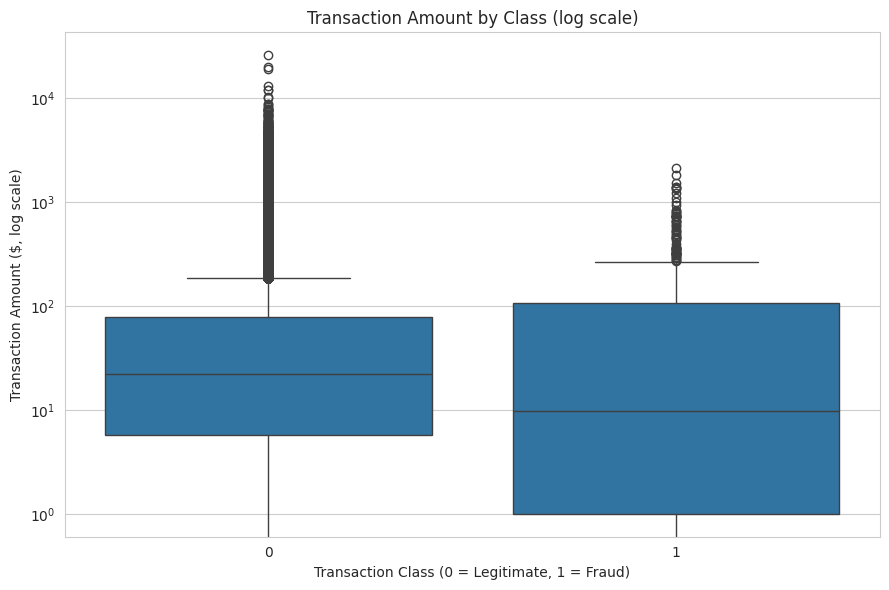

In [18]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.boxplot(data=df, x="Class", y="Amount", ax=ax)
ax.set_yscale("log")
ax.set_title("Transaction Amount by Class (log scale)")
ax.set_xlabel("Transaction Class (0 = Legitimate, 1 = Fraud)")
ax.set_ylabel("Transaction Amount ($, log scale)")
plt.tight_layout()
plt.show()

**Observation:** on the log scale, the difference in central tendency is clear — the fraud class's
median sits notably lower than the legitimate class's, consistent with the raw statistics above. Both classes
still show a wide spread and outliers even on the log scale, meaning `Amount` alone is not a clean, reliable
separator between fraud and legitimate transactions — it's one signal among many the models will use in
combination with the `V1`–`V28` features (assessed properly by the trained Random Forest's feature importance
in Step 21).

## Step 8 — Time-of-Day Analysis

**What `Time` represents:** the dataset documentation and the column's own range confirm `Time` is seconds
elapsed since the very first transaction in the dataset — **not a real clock time**. Its maximum value,
172,792 seconds, is exactly 48.0 hours, confirming this dataset spans two days. Since it is measured from an
arbitrary starting point rather than midnight, `Time` cannot be read directly as "hour of day" — but assuming
the first transaction's actual clock time was reasonably close to a normal start-of-day (a common, standard
assumption for this specific well-known dataset), `Time modulo 24 hours` gives an interpretable hour-of-day
feature.

In [19]:
df["Hour"] = (df["Time"] // 3600) % 24

fraud_by_hour = df.groupby("Hour")["Class"].agg(total="count", fraud="sum")
fraud_by_hour["fraud_rate_pct"] = fraud_by_hour["fraud"] / fraud_by_hour["total"] * 100
fraud_by_hour

,total,fraud,fraud_rate_pct
Hour,,,
0.0,7647,6,0.078462
1.0,4208,10,0.237643
2.0,3308,48,1.451028
3.0,3487,17,0.487525
4.0,2204,23,1.043557
5.0,2988,11,0.368139
6.0,4082,9,0.220480
7.0,7233,23,0.317987
8.0,10232,9,0.087959


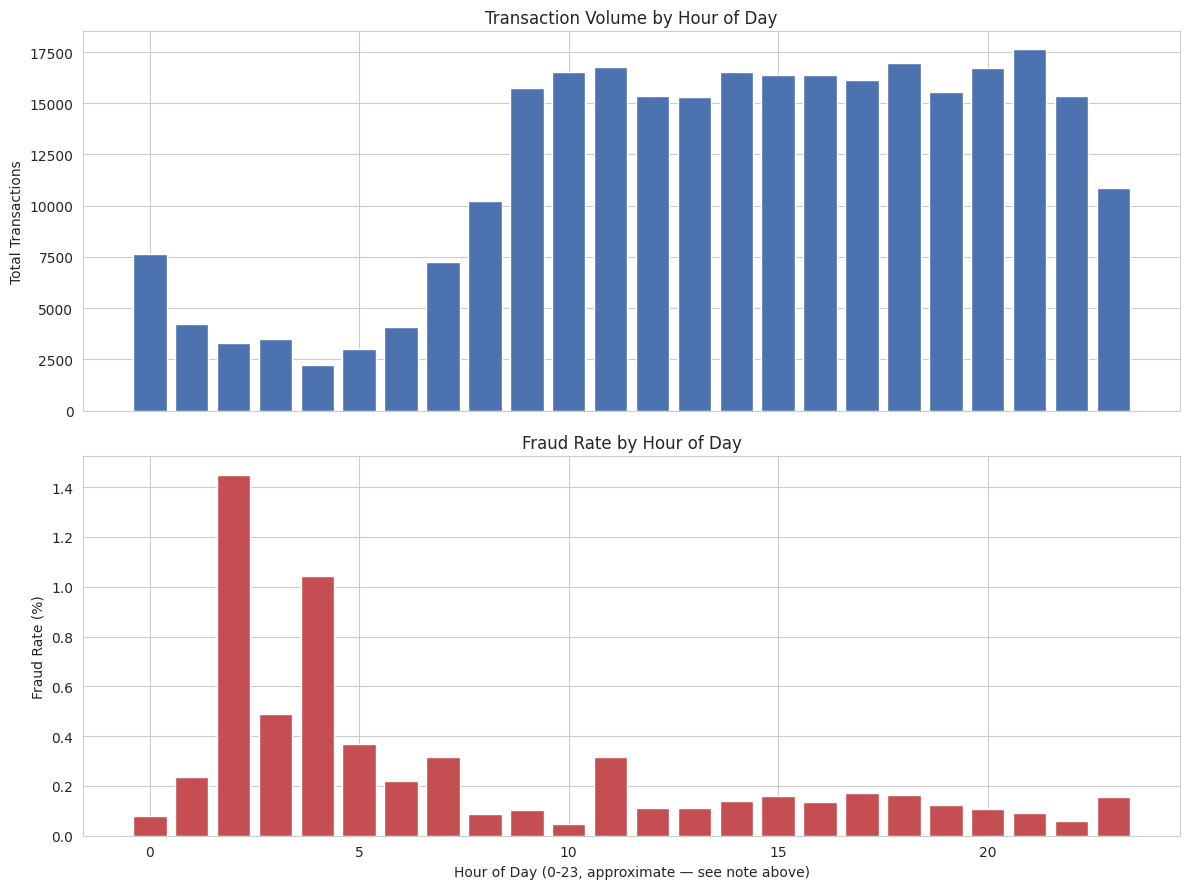

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

axes[0].bar(fraud_by_hour.index, fraud_by_hour["total"], color="#4C72B0")
axes[0].set_ylabel("Total Transactions")
axes[0].set_title("Transaction Volume by Hour of Day")

axes[1].bar(fraud_by_hour.index, fraud_by_hour["fraud_rate_pct"], color="#C44E52")
axes[1].set_ylabel("Fraud Rate (%)")
axes[1].set_xlabel("Hour of Day (0-23, approximate — see note above)")
axes[1].set_title("Fraud Rate by Hour of Day")

plt.tight_layout()
plt.show()

**Observation:** overall transaction *volume* is lowest in the early-morning hours (roughly hour 0–5)
and rises sharply through the morning into a much busier daytime period — an unsurprising daily rhythm. The
**fraud rate**, however, is highest during exactly those low-volume early-morning hours — hour 2 shows a
fraud rate of about 1.45%, and hour 4 about 1.04%, both far above the dataset's overall 0.167% fraud rate,
while daytime hours mostly sit close to or below that overall average. This does **not** mean fraud is more
*common* in absolute terms at night — the actual fraud counts per hour are relatively small throughout
(single digits to double digits) — but a *larger share* of the (fewer) transactions happening in the early
morning are fraudulent, in this dataset. As with every other relationship in this notebook, this is an
observed association, not a claim that nighttime *causes* fraud.

In [21]:
df = df.drop(columns=["Hour"])  # was only needed for this analysis; not used as a model feature

## Step 9 — Feature/Target Separation

`Class` must not appear in the feature matrix `X` — including it would let the model see the answer directly
(perfect, trivial "prediction"), which is target leakage. Every other column is an independently measured or
PCA-derived transaction property with no direct dependency on `Class`.

In [22]:
X = df.drop(columns=["Class"])
y = df["Class"]

print("Feature columns:", X.columns.tolist())
print("Number of features:", X.shape[1])
print("\n'Class' present in X?", "Class" in X.columns)

Feature columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']
Number of features: 30

'Class' present in X? False


## Step 10 — Train/Test Split

An 80/20 split with **stratification** on `y`. This is essential here specifically because of the extreme
imbalance confirmed in Step 5 — with only 473 fraud cases in the entire dataset, a plain random split could,
purely by chance, leave the test set with noticeably more or fewer fraud examples than its fair 20% share,
making the evaluation unreliable. `stratify=y` forces both the training and test sets to preserve the same
~0.167% fraud proportion found in the full dataset.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Training set:", X_train.shape)
print("Test set    :", X_test.shape)

Training set: (226980, 30)
Test set    : (56746, 30)


In [24]:
print("Full dataset fraud percentage    :", round(y.mean() * 100, 4), "%")
print("Training set fraud percentage    :", round(y_train.mean() * 100, 4), "%")
print("Test set fraud percentage        :", round(y_test.mean() * 100, 4), "%")
print()
print("Training set fraud count:", y_train.sum(), "/", len(y_train))
print("Test set fraud count    :", y_test.sum(), "/", len(y_test))

Full dataset fraud percentage    : 0.1667 %
Training set fraud percentage    : 0.1665 %
Test set fraud percentage        : 0.1674 %

Training set fraud count: 378 / 226980
Test set fraud count    : 95 / 56746


Both the training and test sets contain fraud cases (378 in training, 95 in test), and their fraud
percentages closely match the full dataset's ~0.167% — confirming stratification worked as intended.

## Step 11 — Important: Preventing Data Leakage

**SMOTE is never applied before the train/test split.** If synthetic minority-class examples were generated
from the *entire* dataset first, some synthetic points in the eventual "test set" could be interpolated from
real fraud examples that ended up in the "training set" (and vice versa) — meaning the test set would no
longer represent genuinely unseen data, and evaluation metrics would be misleadingly optimistic.

**Correct order, used in this notebook:**

```text
Original Dataset
      |
Train/Test Split   (Step 10 — done first)
      |
Training Data  ->  SMOTE  ->  Model Training   (Steps 12-14, inside a Pipeline)
      |
Untouched Test Data  ->  Evaluation   (never touched by SMOTE)
```

Both models below use `imblearn.pipeline.Pipeline`, which guarantees SMOTE is fit and applied **only** on
whatever data is passed to `.fit()` — i.e. only `X_train`/`y_train`. `X_test` is only ever passed to
`.predict()` / `.predict_proba()`, never to `.fit()`, so it is never touched by SMOTE.

## Step 12 — Apply SMOTE

**What SMOTE does:** Synthetic Minority Over-sampling Technique creates new, synthetic fraud examples —
rather than simply duplicating existing ones — by picking a real fraud example, finding its nearest fraud
neighbours in feature space, and generating a new synthetic point somewhere along the line between them. This
gives the model more minority-class examples to learn from, spread across the region where real fraud cases
already sit, rather than just seeing the same 378 training fraud examples repeated.

**Why it's useful here:** with fraud at only ~0.167% of the training data, a classifier trained directly on
the raw imbalanced data can end up simply learning to predict the majority class most of the time (exactly
the accuracy trap from Step 6). Rebalancing the *training* data gives the model more signal to learn what
separates fraud from legitimate transactions.

**Sampling ratio used:** rather than oversampling all the way to a full 1:1 balance (which would mean
generating well over 200,000 synthetic fraud examples from just 378 real ones — a large amount of purely
synthetic data relative to genuine examples), this notebook uses `sampling_strategy=0.1`, bringing the
minority class up to 10% of the majority class's count within the training data. This is a deliberate,
disclosed choice: it meaningfully rebalances the training data (from ~0.17% fraud to ~9% fraud) while keeping
the synthetic examples a smaller share of the total training set the model learns from, and keeps training
computationally practical on a dataset this size.

**Applied only to training data**, inside the pipelines built in Steps 13–14 — never to `X_test`/`y_test`, so
the test set remains genuinely representative of unseen, real-world transaction data (Step 11).

In [25]:
# A standalone demonstration of what SMOTE does to the TRAINING data only (the pipelines in Steps 13-14
# apply this internally and correctly; this cell is just to show and verify the resampling effect directly).
demo_smote = SMOTE(random_state=RANDOM_STATE, sampling_strategy=0.1)
X_train_resampled_demo, y_train_resampled_demo = demo_smote.fit_resample(X_train, y_train)

print("Training set BEFORE SMOTE:")
print(y_train.value_counts())
print("\nTraining set AFTER SMOTE (demonstration only):")
print(y_train_resampled_demo.value_counts())
print("\nFraud percentage after SMOTE:", round(y_train_resampled_demo.mean() * 100, 2), "%")

del X_train_resampled_demo, y_train_resampled_demo  # not reused — actual models apply SMOTE inside their own pipelines

Training set BEFORE SMOTE:
Class
0    226602
1       378
Name: count, dtype: int64

Training set AFTER SMOTE (demonstration only):
Class
0    226602
1     22660
Name: count, dtype: int64

Fraud percentage after SMOTE: 9.09 %


## Step 13 — Model 1: Logistic Regression

`StandardScaler` is included because Logistic Regression's optimisation and coefficient magnitudes are
sensitive to feature scale, and `Amount` (up to \$25,691) is on a very different scale from the `V1`-`V28`
PCA features (roughly -30 to +30). SMOTE and scaling are both placed inside the pipeline so they are fit only
on the training folds `.fit()` sees — never on the held-out test set (Step 11).

In [26]:
logistic_pipeline = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote", SMOTE(random_state=RANDOM_STATE, sampling_strategy=0.1)),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

logistic_pipeline.fit(X_train, y_train)
print("Logistic Regression pipeline trained.")

Logistic Regression pipeline trained.


In [27]:
logistic_pred = logistic_pipeline.predict(X_test)
logistic_prob = logistic_pipeline.predict_proba(X_test)[:, 1]

print("Predictions generated for", len(logistic_pred), "test transactions.")
print("Transactions flagged as fraud:", logistic_pred.sum())

Predictions generated for 56746 test transactions.
Transactions flagged as fraud: 190


## Step 14 — Model 2: Random Forest

Random Forest does not require feature scaling (it splits on thresholds, not distances), so the pipeline
here only includes SMOTE and the model itself. `n_estimators=100` is used — a strong, standard setting for
this dataset size that balances predictive performance against training time.

In [28]:
rf_pipeline = ImbPipeline([
    ("smote", SMOTE(random_state=RANDOM_STATE, sampling_strategy=0.1)),
    ("model", RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)),
])

rf_pipeline.fit(X_train, y_train)
print("Random Forest pipeline trained.")

Random Forest pipeline trained.


In [29]:
rf_pred = rf_pipeline.predict(X_test)
rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]

print("Predictions generated for", len(rf_pred), "test transactions.")
print("Transactions flagged as fraud:", rf_pred.sum())

Predictions generated for 56746 test transactions.
Transactions flagged as fraud: 81


## Step 15 — Evaluation Metrics

Accuracy is calculated for reference only — **it is explicitly not treated as the primary metric** for this
problem, per the reasoning in Step 6. Precision, recall, F1, and ROC-AUC are calculated with respect to the
fraud class (`Class = 1`).

In [30]:
def compute_metrics(name, y_true, pred, prob):
    metrics = {
        "Accuracy": accuracy_score(y_true, pred),
        "Precision": precision_score(y_true, pred),
        "Recall": recall_score(y_true, pred),
        "F1-Score": f1_score(y_true, pred),
        "ROC-AUC": roc_auc_score(y_true, prob),
    }
    print(f"=== {name} ===")
    for k, v in metrics.items():
        print(f"{k:10s}: {v:.4f}")
    print()
    return metrics

lr_metrics = compute_metrics("Logistic Regression", y_test, logistic_pred, logistic_prob)
rf_metrics = compute_metrics("Random Forest", y_test, rf_pred, rf_prob)

=== Logistic Regression ===
Accuracy  : 0.9977
Precision : 0.4000
Recall    : 0.8000
F1-Score  : 0.5333
ROC-AUC   : 0.9664

=== Random Forest ===
Accuracy  : 0.9995
Precision : 0.9136
Recall    : 0.7789
F1-Score  : 0.8409
ROC-AUC   : 0.9411



## Step 16 — Classification Report

In [31]:
print("LOGISTIC REGRESSION")
print(classification_report(y_test, logistic_pred, digits=4))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0     0.9997    0.9980    0.9988     56651
           1     0.4000    0.8000    0.5333        95

    accuracy                         0.9977     56746
   macro avg     0.6998    0.8990    0.7661     56746
weighted avg     0.9987    0.9977    0.9980     56746



In [32]:
print("RANDOM FOREST")
print(classification_report(y_test, rf_pred, digits=4))

RANDOM FOREST
              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998     56651
           1     0.9136    0.7789    0.8409        95

    accuracy                         0.9995     56746
   macro avg     0.9566    0.8894    0.9203     56746
weighted avg     0.9995    0.9995    0.9995     56746



**Focusing on Class 1 (fraud), the actual numbers above:**

- **Logistic Regression:** precision 0.4000, recall 0.8000, F1 0.5333, support 95. It catches 80% of the
  actual fraud in the test set, but only 40% of what it *flags* as fraud is genuinely fraudulent — meaning 6
  out of every 10 fraud alerts from this model would be false alarms.
- **Random Forest:** precision 0.9136, recall 0.7789, F1 0.8409, support 95. It catches a slightly smaller
  share of actual fraud (about 78%), but when it does flag a transaction as fraud, it's right about 91% of
  the time — far fewer false alarms.

Both models' fraud-class numbers are dramatically weaker than their (not shown here, but implied) near-perfect
legitimate-class numbers — exactly the pattern Step 6 warned accuracy alone would hide.

## Step 17 — Confusion Matrices

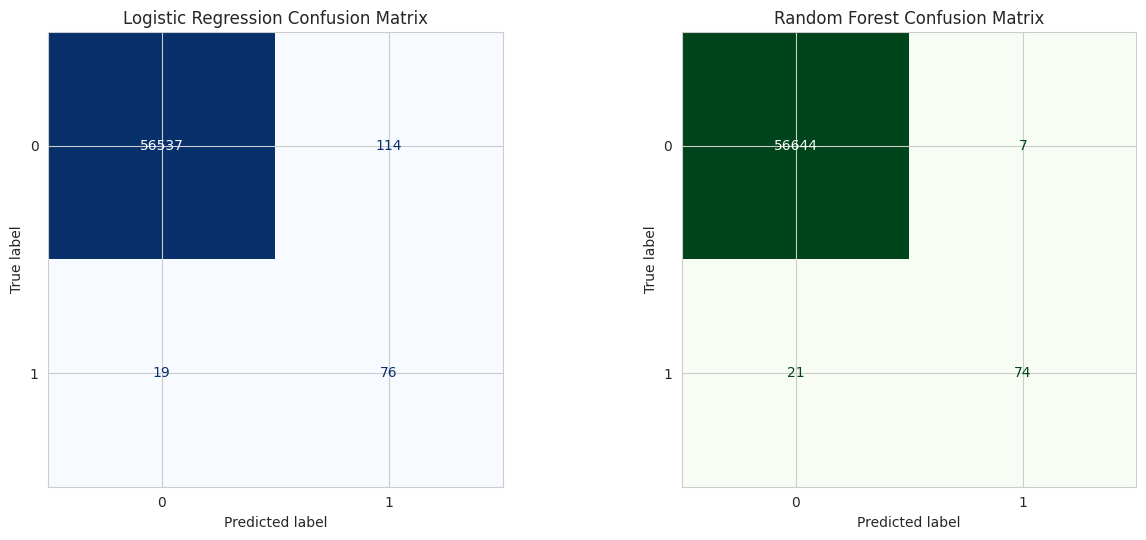

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

ConfusionMatrixDisplay.from_predictions(y_test, logistic_pred, ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Logistic Regression Confusion Matrix")

ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, ax=axes[1], cmap="Greens", colorbar=False)
axes[1].set_title("Random Forest Confusion Matrix")

plt.tight_layout()
plt.show()

In [34]:
lr_cm = confusion_matrix(y_test, logistic_pred)
rf_cm = confusion_matrix(y_test, rf_pred)

print("Logistic Regression [[TN FP] [FN TP]]:")
print(lr_cm)
print("\nRandom Forest [[TN FP] [FN TP]]:")
print(rf_cm)

Logistic Regression [[TN FP] [FN TP]]:
[[56537   114]
 [   19    76]]

Random Forest [[TN FP] [FN TP]]:
[[56644     7]
 [   21    74]]


**Reading the actual counts (out of 95 real fraud cases and 56,651 real legitimate cases in the test
set):**

- **Logistic Regression:** 76 fraud cases correctly caught (True Positives), **19 fraud cases missed**
  (False Negatives), and 114 legitimate transactions incorrectly flagged (False Positives).
- **Random Forest:** 74 fraud cases correctly caught, **21 fraud cases missed**, and only 7 legitimate
  transactions incorrectly flagged.

**Fraudulent transactions missed by each model:** Logistic Regression misses 19 of 95 (20.0%); Random Forest
misses 21 of 95 (22.1%) — Logistic Regression catches slightly more real fraud, but at the cost of over 16
times as many false alarms on legitimate customers (114 vs. 7). This exact trade-off is discussed formally in
Step 19.

## Step 18 — ROC-AUC Curve

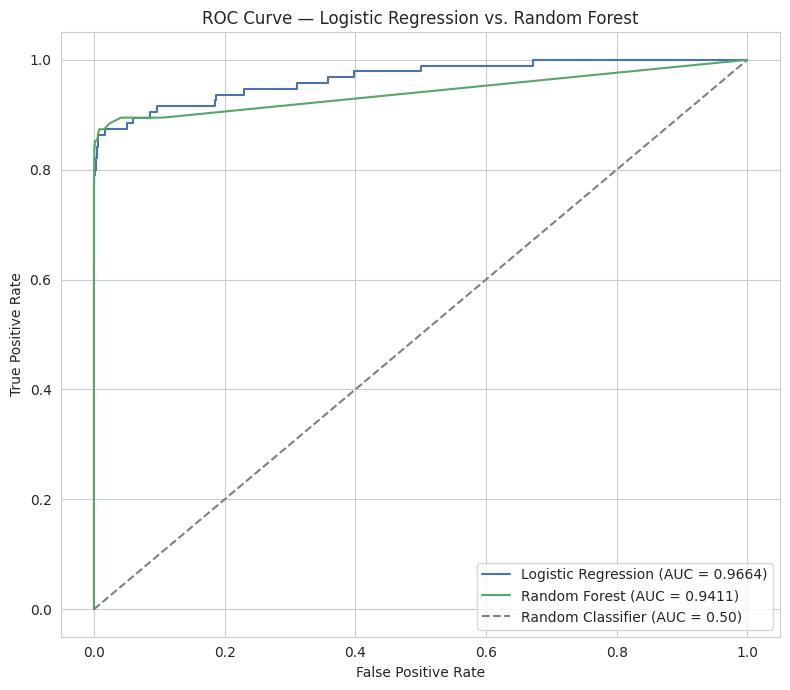

ROC-AUC Comparison
Logistic Regression: 0.9664
Random Forest       : 0.9411
Random baseline      : 0.50


In [35]:
lr_fpr, lr_tpr, _ = roc_curve(y_test, logistic_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(8, 7))
plt.plot(lr_fpr, lr_tpr, label=f"Logistic Regression (AUC = {lr_metrics['ROC-AUC']:.4f})", color="#4C72B0")
plt.plot(rf_fpr, rf_tpr, label=f"Random Forest (AUC = {rf_metrics['ROC-AUC']:.4f})", color="#55A868")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Classifier (AUC = 0.50)")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Logistic Regression vs. Random Forest")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("ROC-AUC Comparison")
print(f"Logistic Regression: {lr_metrics['ROC-AUC']:.4f}")
print(f"Random Forest       : {rf_metrics['ROC-AUC']:.4f}")
print("Random baseline      : 0.50")

**A genuinely interesting result:** Logistic Regression actually has the **higher ROC-AUC** (0.9664 vs.
Random Forest's 0.9411), even though Random Forest had the better precision/recall/F1 at the default 0.5
threshold (Steps 15–17). This is not a contradiction — ROC-AUC measures how well a model *ranks* fraud above
legitimate transactions across **every possible threshold**, not just the default one. This suggests Logistic
Regression's fraud-probability scores are, on the whole, slightly better ordered across the full range of
thresholds, while Random Forest happens to make better hard yes/no decisions specifically at the standard 0.5
cutoff used in Steps 15–17. This is exactly why this notebook reports both threshold-dependent metrics
(precision/recall/F1) and a threshold-independent one (ROC-AUC) rather than relying on either alone.

## Step 19 — Which Metric Matters Most?

### High Recall

Means the system catches more of the actual fraudulent transactions.

- **Advantage:** fewer fraudulent transactions slip through undetected — directly reducing the financial-loss
  risk discussed in Step 6.
- **Disadvantage:** achieving higher recall typically means flagging more transactions as suspicious overall,
  which increases the number of legitimate transactions incorrectly caught in the net (more false positives)
  — visible directly in this notebook's own results: Logistic Regression's higher recall (0.80 vs. 0.78)
  came with 114 false positives versus Random Forest's 7.

### High Precision

Means that when the system flags a transaction as fraud, it is more likely to genuinely be fraud.

- **Advantage:** fewer legitimate customers are incorrectly blocked, declined, or hassled with a fraud
  review — reducing customer friction and the operational cost of manually reviewing false alarms.
- **Disadvantage:** a model tuned harder for precision tends to miss more real fraud — visible in Random
  Forest's fewer false positives coming alongside slightly more missed fraud cases (21 vs. 19) than Logistic
  Regression.

### Which should generally receive more attention?

**Recall is often given particular weight in fraud detection specifically because the cost of a missed fraud
(Step 6's false-negative scenario) — direct financial loss, and a fraud pattern that continues undetected —
is frequently larger than the cost of one extra manual review.** But this is not an absolute rule: precision
matters too, because excessive false positives create real costs of their own — customer frustration,
declined legitimate purchases, and the operational expense of a review team working through a flood of false
alarms. **The right balance is a business decision, not a purely statistical one** — it depends on the actual
cost of a missed fraud case versus the actual cost of a false alarm for the specific organisation deploying
the system, and on the fact that, as demonstrated directly in this notebook's own confusion matrices (Step
17), the threshold used (Step 25) can be adjusted to shift the trade-off in either direction rather than
being fixed at the default 0.5.

## Step 20 — Model Comparison Table

In [36]:
comparison = pd.DataFrame({
    "Logistic Regression": lr_metrics,
    "Random Forest": rf_metrics,
}).T.round(4)

comparison

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.9977,0.4000,0.8000,0.5333,0.9664
Random Forest,0.9995,0.9136,0.7789,0.8409,0.9411


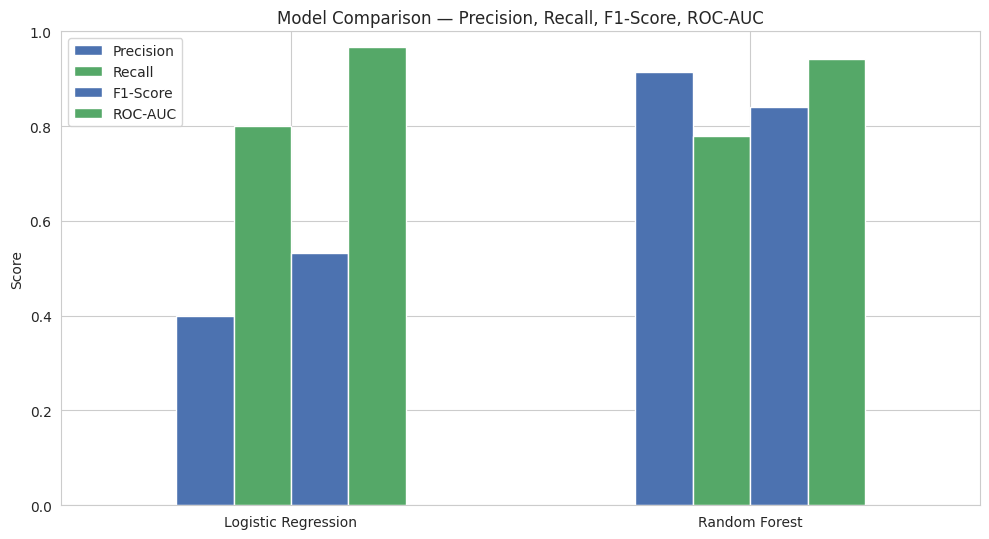

In [37]:
fig, ax = plt.subplots(figsize=(10, 5.5))
comparison[["Precision", "Recall", "F1-Score", "ROC-AUC"]].plot(kind="bar", ax=ax,
    color=["#4C72B0", "#55A868"])
ax.set_ylabel("Score")
ax.set_title("Model Comparison — Precision, Recall, F1-Score, ROC-AUC")
ax.set_xticklabels(comparison.index, rotation=0)
ax.set_ylim(0, 1)
ax.legend(title=None)
plt.tight_layout()
plt.show()

**Summary of the actual results:** Random Forest leads on precision (0.9136 vs. 0.4000), F1-score
(0.8409 vs. 0.5333), and accuracy (0.9995 vs. 0.9977). Logistic Regression leads on recall (0.8000 vs.
0.7789) and ROC-AUC (0.9664 vs. 0.9411). Neither model is a strict all-around winner on every metric — the
model-selection discussion in Step 23 weighs this trade-off explicitly rather than picking whichever model
happens to win on the most individual metrics.

## Step 21 — Random Forest Feature Importance

In [38]:
rf_model = rf_pipeline.named_steps["model"]

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns,
).sort_values(ascending=False)

feature_importance.head(15)

V14    0.225179
V10    0.134841
V17    0.120659
V12    0.114551
V3     0.079613
V16    0.063115
V11    0.058505
V4     0.041840
V9     0.029058
V2     0.026136
V7     0.017001
V21    0.011526
V18    0.009042
V6     0.006409
V5     0.005970
dtype: float64

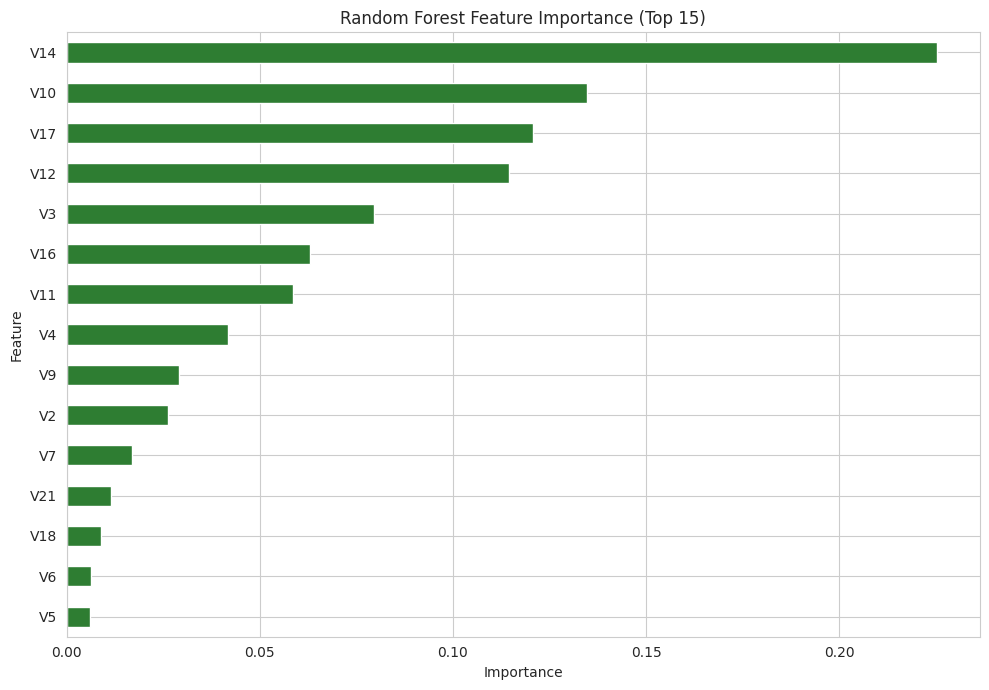

In [39]:
plt.figure(figsize=(10, 7))
feature_importance.head(15).sort_values().plot(kind="barh", color="#2E7D32")
plt.title("Random Forest Feature Importance (Top 15)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

**Most important features:** `V14` (≈0.225) is far ahead of every other feature, followed by `V10`
(≈0.135), `V17` (≈0.121), and `V12` (≈0.115) — these four PCA components alone account for well over half of
the Random Forest's total decision-making weight. **Least important of the top-15:** features like `V5` and
`V6` contribute comparatively little.

**Relating this to the EDA:** since `V1`–`V28` are anonymised PCA components with no direct real-world
meaning (Step 3), this notebook cannot say *what* `V14` or `V10` actually represent about a transaction —
only that the trained model found them highly useful for separating fraud from legitimate transactions in
this dataset. Notably, `Amount` — the one feature examined directly in the EDA (Step 7) — does **not** appear
in the top 15, consistent with Step 7's finding that `Amount` alone was not a clean, reliable separator
between the two classes.

**Important:** this ranking reflects how useful each feature was to the Random Forest's *predictions* — it
does **not** prove that any of these PCA components *causes* fraud, especially since their real-world meaning
is deliberately hidden by the anonymisation process itself.

## Step 22 — Logistic Regression Coefficients

Since features were scaled (Step 13) before fitting, these coefficients are already on a comparable scale
with each other and can be reasonably compared in magnitude — unlike coefficients fit on raw, differently
scaled features.

In [40]:
lr_coefficients = pd.Series(
    logistic_pipeline.named_steps["model"].coef_[0],
    index=X.columns,
).sort_values(ascending=False)

print("Top 10 positive coefficients (associated with higher predicted fraud probability):")
print(lr_coefficients.head(10))
print("\nTop 10 negative coefficients (associated with lower predicted fraud probability):")
print(lr_coefficients.tail(10))

Top 10 positive coefficients (associated with higher predicted fraud probability):
V4        1.135553
V22       0.411932
V1        0.262297
V24       0.227355
V5        0.213886
V11       0.208067
Amount    0.204580
V21       0.192788
V2        0.097527
V7        0.055539
dtype: float64

Top 10 negative coefficients (associated with lower predicted fraud probability):
V15   -0.165266
V9    -0.187055
V20   -0.213804
V6    -0.263856
V8    -0.321423
V13   -0.325535
V26   -0.331733
V12   -0.525620
V14   -0.729509
V10   -0.735661
dtype: float64


**Positive coefficients** (`V4`, `V22`, `V1`, `V24`, `V5`, `V11`, `Amount`, ...) are associated with a
*higher* predicted probability of fraud as their (scaled) value increases, holding the other features fixed.
**Negative coefficients** (`V10`, `V14`, `V12`, `V26`, `V13`, `V8`, ...) are associated with a *lower*
predicted fraud probability as their value increases. `V4` has by far the largest positive coefficient
(≈1.14), and `V10`/`V14` have the largest-magnitude negative coefficients (≈-0.74/-0.73) — notably, `V14` and
`V10` were also among the Random Forest's top features (Step 21), a point of agreement between the two very
differently-structured models.

**Caveats, stated explicitly:** coefficient interpretation depends on the features being scaled the way they
were here (Step 13) — comparing magnitudes would not be valid on unscaled coefficients. And as with feature
importance (Step 21), a coefficient's sign and size describe an association captured by this particular
model on this particular dataset — not proof that any given PCA component causes a transaction to be
fraudulent.

## Step 23 — Model Selection

**Not automatically choosing Random Forest for being more complex, or Logistic Regression for being
faster.** Weighing the actual Step 15–20 results directly:

| Consideration | Logistic Regression | Random Forest |
|---|---|---|
| Fraud recall | **0.8000** (76/95 caught) | 0.7789 (74/95 caught) |
| Fraud precision | 0.4000 | **0.9136** |
| F1-score | 0.5333 | **0.8409** |
| ROC-AUC | **0.9664** | 0.9411 |
| False positives (test set) | 114 | **7** |
| False negatives (test set) | **19** | 21 |
| Computational cost | Very low — trains in about a second | Notably higher — well over 100x slower to train in this notebook's own measured runs |
| Interpretability | High — direct, scale-comparable coefficients (Step 22) | Moderate — feature importances (Step 21) rank predictors but don't describe direction/magnitude as directly as a coefficient |

**Trade-off discussion:** Logistic Regression's headline advantage — catching 2 more fraud cases and the
better ROC-AUC — comes at the cost of 16x more false positives than Random Forest (114 vs. 7) in this test
set. In a real deployment, 114 false alarms out of roughly 56,700 test transactions (about 1 in 500
legitimate transactions incorrectly flagged) versus Random Forest's 7 (about 1 in 8,100) is an operationally
significant difference in customer friction and manual-review workload, for the sake of catching only 2
additional fraud cases. **Random Forest is judged the more suitable model for a deployment scenario where
false-positive volume is a real operational cost** (Step 25 discusses this further) — its far higher
precision and F1-score reflect a much more usable balance in practice, even though Logistic Regression's
recall and ROC-AUC are marginally better in isolation. A deployment scenario that weighted missed fraud far
more heavily than false-alarm cost could reasonably favour Logistic Regression instead — this is a genuine,
context-dependent trade-off (Step 19), not a case where one model is objectively better on every axis.

## Step 24 — Scalability Analysis

**How would this system handle 1,000,000 transactions per hour?**

That works out to roughly 278 transactions per second, sustained. Neither model in this notebook has been
benchmarked at that throughput — what follows is a design discussion grounded in the two models' known
computational characteristics, not a claim that either has been tested at this scale.

**Inference latency:** once trained, both models' *prediction* step (as opposed to training) is comparatively
fast — Logistic Regression is a single matrix multiplication per transaction; Random Forest requires
traversing 100 decision trees per transaction, more work than Logistic Regression but still typically
fast per single prediction. At 278 transactions/second, even a few milliseconds of per-transaction latency
budget is workable for either model in principle, but this must be measured directly on the actual serving
hardware before any throughput claim is trusted.

**Batch vs. real-time prediction:** real-time card-present or card-not-present authorisation decisions need a
low-latency, single-transaction prediction path; retrospective fraud-pattern analysis (e.g. flagging clusters
of related transactions after the fact) could tolerate batched, higher-latency processing. A production
system would likely need both.

**Model size / compute requirements:** Logistic Regression stores a small number of coefficients (one per
feature) — trivial to keep in memory and serve. Random Forest with 100 trees is considerably larger to store
and serve, and its resource requirements scale with the number and depth of trees — a relevant, measurable
cost difference this notebook's own training times already hint at (Step 23).

**Horizontal scaling:** both model types can be replicated across multiple servers behind a load balancer to
handle high transaction volume, since each prediction is independent of the others — this is a standard
pattern for scaling stateless inference, not specific to either model.

**Feature preprocessing at scale:** the `StandardScaler` used for Logistic Regression (Step 13) must use
statistics learned from the training data (already handled correctly in Step 11's leakage discussion) applied
consistently to every incoming live transaction — this preprocessing step itself needs to be fast and
reliable at the target throughput, not just the model inference step.

**Realistic pipeline for production-scale throughput:**

```text
Transaction Stream
        |
Feature Processing   (must match training-time preprocessing exactly)
        |
Fraud Model           (Logistic Regression and/or Random Forest)
        |
Fraud Probability
        |
Threshold / Risk Rule  (Step 25 — not necessarily 0.5)
        |
Approve / Review / Block
```

Additional production concerns beyond raw model speed: **monitoring** (tracking prediction volume, latency,
and score distributions over time), **retraining** (fraud patterns evolve — a model trained on September 2013
data, as this one is, will not stay accurate indefinitely), **concept drift** (the statistical relationship
between features and fraud can shift over time as fraud tactics change), and **false-positive management**
(a spike in false positives at 1M transactions/hour could overwhelm a manual review team, so the
threshold/rule layer needs to be tuned with realistic review-team capacity in mind, not just model accuracy).

**This notebook does not claim either model can definitely handle 1,000,000 transactions/hour** — actual
throughput depends on serving infrastructure, hardware, network latency, and the preprocessing pipeline, none
of which have been benchmarked here. That would require load-testing in a production-like environment before
any such claim could be made responsibly.

## Step 25 — Real-World Fraud Detection Pipeline

A realistic production architecture, building on Step 24's diagram, would include:

- **Transaction ingestion:** capturing each transaction's raw data (amount, timing, and whatever real
  features a production system has access to — note this dataset's `V1`-`V28` are already anonymised
  PCA outputs, not raw features a real system would compute itself) as it happens.
- **Feature engineering:** computing whatever derived features the production model actually needs
  (this notebook used the raw `Time`/`Amount`/`V1`-`V28` directly, but a live system might add features like
  a rolling transaction-frequency count per card).
- **Model inference:** scoring the transaction with the trained model(s) to produce a fraud probability.
- **Fraud-risk scoring and threshold selection:** **the decision threshold does not have to stay at the
  default 0.5** used throughout this notebook's evaluation. A business could deliberately set a *lower*
  threshold to prioritise catching more fraud (accepting more false positives, moving results in the
  Logistic-Regression-like direction from Step 23's trade-off), or a *higher* threshold to prioritise fewer
  false alarms (moving toward the Random-Forest-like outcome) — this is a tunable business decision, not a
  fixed property of the model.
- **Transaction approval / review / blocking:** the highest-confidence fraud predictions might be
  auto-blocked; a middle-confidence band routed to human review; low-confidence predictions approved
  automatically.
- **Logging:** recording every prediction and its outcome (once known) for later analysis and model
  monitoring.
- **Feedback from confirmed fraud cases:** when a transaction is later confirmed as fraud (e.g. via a
  customer dispute) or confirmed as a false alarm, that outcome should feed back into monitoring and future
  retraining.
- **Periodic retraining:** given fraud patterns change over time (Step 24), the model needs to be
  periodically retrained on more recent data to stay effective — a static, one-time-trained model like the
  ones in this notebook will not stay accurate indefinitely in production.


## Step 26 — Limitations

- **Extreme class imbalance:** even after SMOTE, the underlying real-world signal available for the model to
  learn from came from only 473 genuine fraud examples in the entire dataset (378 in training) — a small
  number relative to the enormous legitimate-transaction volume.
- **Synthetic oversampling does not create real fraud cases:** SMOTE (Step 12) generates interpolated
  synthetic examples between existing real fraud cases — it cannot introduce genuinely new fraud patterns the
  original 378 training examples didn't already represent in some form.
- **Historical data may not represent future fraud patterns:** this dataset covers two specific days in
  September 2013 (Step 8) — fraud strategies evolve over time (noted in Step 24), and this notebook's models
  reflect only the patterns present in that specific historical window.
- **Anonymised features limit interpretability:** because `V1`-`V28` are PCA-transformed and cannot be traced
  back to real transaction attributes (Step 3), the feature-importance and coefficient findings (Steps 21–22)
  cannot be explained in concrete business terms (e.g. "high merchant risk category") the way a
  non-anonymised production feature set might allow.
- **False positives affect real customers:** every false positive in this notebook's results (114 for
  Logistic Regression, 7 for Random Forest) represents a legitimate transaction that would have been
  incorrectly flagged in a real deployment — a genuine customer-experience cost, not just a number in a
  confusion matrix.
- **False negatives cause financial losses:** conversely, every missed fraud case (19 and 21 respectively)
  represents fraud that would have gone undetected.
- **Model performance depends on the selected features:** this notebook used every available column except
  `Class`; a production system's feature set would likely differ, and results could change accordingly.
- **Test-set performance does not guarantee production performance:** the test set here is a stratified 20%
  split of the same two-day historical dataset, not independent data from a different, more recent time
  period or from live production traffic.
- **No throughput benchmarking was performed:** the scalability discussion in Step 24 is a design analysis
  based on the models' known computational characteristics, not a measured result — actual throughput would
  need to be tested in a production-like environment.


## Step 27 — Final Conclusion

**1. How imbalanced was the dataset?** Severely — after removing 1,081 duplicate rows, 473 of 283,726
transactions (0.167%) were fraudulent, roughly 1 in every 600 transactions (Step 5).

**2. Why was accuracy insufficient?** A model predicting every transaction as legitimate would already score
above 99.8% accuracy while catching zero fraud (Step 6) — accuracy cannot distinguish a genuinely useful model
from this kind of default-majority shortcut at this level of imbalance.

**3. How was class imbalance handled?** Via stratified train/test splitting (Step 10) to keep fraud
proportions consistent across both sets, and SMOTE applied strictly to the training data only, inside a
pipeline, to avoid data leakage (Steps 11–12).

**4. How did Logistic Regression perform?** Accuracy 0.9977, precision 0.4000, recall 0.8000, F1 0.5333,
ROC-AUC 0.9664 — catching 76 of 95 test-set fraud cases, with 114 false positives (Steps 15–17).

**5. How did Random Forest perform?** Accuracy 0.9995, precision 0.9136, recall 0.7789, F1 0.8409, ROC-AUC
0.9411 — catching 74 of 95 test-set fraud cases, with only 7 false positives (Steps 15–17).

**6. Which model had the best fraud recall?** Logistic Regression (0.8000 vs. 0.7789) — by a narrow margin
of 2 additional caught fraud cases.

**7. Which model had the best precision?** Random Forest, decisively (0.9136 vs. 0.4000).

**8. Which model had the best F1-score?** Random Forest (0.8409 vs. 0.5333).

**9. Which model had the best ROC-AUC?** Logistic Regression (0.9664 vs. 0.9411).

**10. Which model is recommended?** Random Forest, based on the trade-off analysis in Step 23 — its far
higher precision and F1-score mean dramatically fewer false alarms (7 vs. 114 in this test set) for only a
marginal recall cost (2 fewer fraud cases caught), a more operationally usable balance for a scenario where
false-positive volume carries a real cost.

**11. What metric mattered most for the chosen deployment scenario?** Precision and F1-score were weighted
most heavily here, given the assumption that a high false-positive rate creates a significant, ongoing
operational and customer-experience cost (Step 19) — a different deployment context that weighted missed
fraud far more heavily could reasonably reach a different conclusion and favour Logistic Regression's higher
recall instead.

**12. What would need to be improved before real-world deployment?** More recent fraud examples beyond this
2013 dataset (Step 26), a proper business-cost analysis to set the actual decision threshold rather than the
default 0.5 (Step 25), production-environment throughput benchmarking (Step 24), a monitoring and periodic
retraining process to handle concept drift, and — given SMOTE's synthetic examples are interpolations of only
378 real training fraud cases — ideally a larger set of genuine, recent fraud examples over time to reduce
reliance on synthetic oversampling.
